<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_8_Video_Classification_CNN%E2%80%93RNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 8: Video Classification Using a CNN–RNN Model

# Step 1: Upload Dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving sample-5s.webm to sample-5s.webm
Saving sample-5s.mp4 to sample-5s.mp4


# Step 2: Import Libraries

In [2]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Step 3: Extract Frames from Videos

In [3]:
def extract_frames(video_path, num_frames=20, img_size=(224,224)):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        return np.zeros((num_frames, 224, 224, 3))

    indices = np.linspace(0, max(total_frames-1,1), num_frames).astype(int)

    for i in range(total_frames):
        ret, frame = cap.read()
        if not ret:
            break
        if i in indices:
            frame = cv2.resize(frame, img_size)
            frame = frame / 255.0
            frames.append(frame)

    cap.release()

    while len(frames) < num_frames:
        frames.append(frames[-1] if frames else np.zeros((224,224,3)))

    return np.array(frames)

# Step 4: Load Videos and Assign Labels

In [4]:
video_files = list(uploaded.keys())

def get_label(name):
    return 0 if name.startswith("action") else 1

videos, labels = [], []

for file in video_files:
    frames = extract_frames(file)
    videos.append(frames)
    labels.append(get_label(file))

videos = np.array(videos)
labels = np.array(labels)

print("Videos shape:", videos.shape)
print("Labels shape:", labels.shape)

Videos shape: (2, 20, 224, 224, 3)
Labels shape: (2,)


# Step 5: Visualize Sample Frames

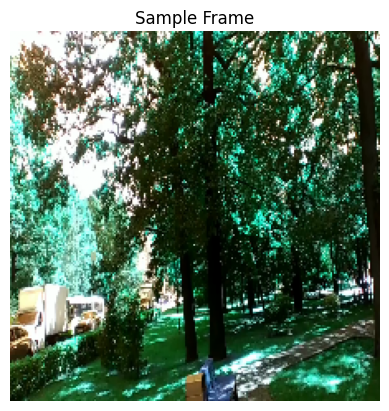

In [5]:
plt.imshow(videos[0][0])
plt.title("Sample Frame")
plt.axis('off')
plt.show()

# Step 6: Train-Test Split

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    videos, labels, test_size=0.2, random_state=42
)

# Step 7: Create tf.data Pipeline

In [7]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))

train_ds = train_ds.shuffle(10).batch(1).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(1).prefetch(tf.data.AUTOTUNE)

# Step 8: Build CNN-RNN Model

In [8]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.TimeDistributed(base_model, input_shape=(20,224,224,3)),
    tf.keras.layers.TimeDistributed(tf.keras.layers.GlobalAveragePooling2D()),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 20, 7, 7, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 20, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │       344,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,604,417 (9.94 MB)

 Trainable params: 346,433 (1.32 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Step 9: Train Model with Validation

In [9]:
history = model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 121s 121s/step - accuracy: 0.0000e+00 - loss: 0.7116 - val_accuracy: 1.0000 - val_loss: 0.2652
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.2775 - val_accuracy: 1.0000 - val_loss: 0.1243
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.1293 - val_accuracy: 1.0000 - val_loss: 0.0754
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0770 - val_accuracy: 1.0000 - val_loss: 0.0528
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0538 - val_accuracy: 1.0000 - val_loss: 0.0395


# Step 10: Plot Training Metrics

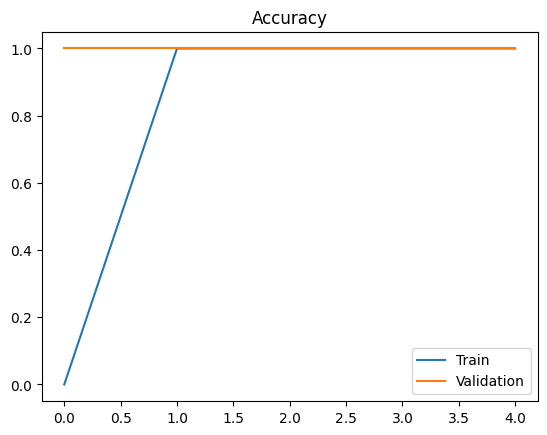

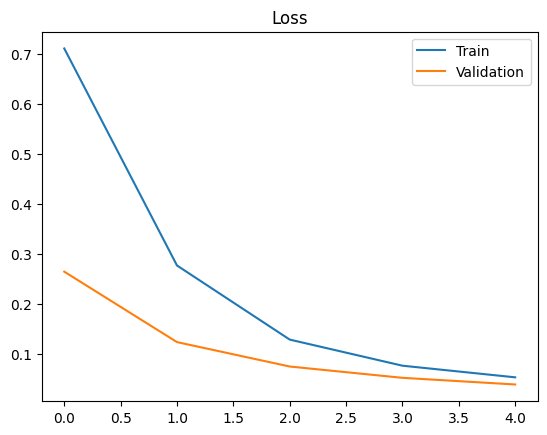

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# Step 11: Visualize Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 30s 30s/step


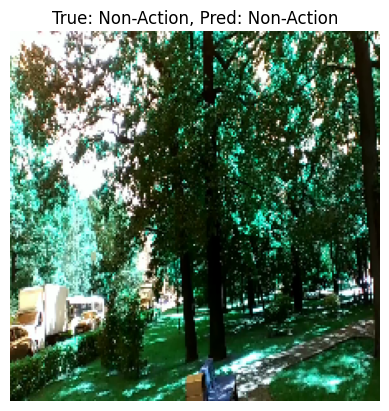

In [11]:
label_map = {0: 'Action', 1: 'Non-Action'}

for x, y in val_ds.take(1):
    pred = model.predict(x)
    for i in range(len(x)):
        plt.imshow(x[i][0])
        plt.title(f"True: {label_map[int(y[i].numpy())]}, Pred: {label_map[int(pred[i][0] > 0.5)]}")
        plt.axis('off')
        plt.show()

# Analysis

# Data Pipeline and Video Preprocessing
By using tf.data to efficiently load and process video data. Each video was converted into a fixed number of frames (20) using OpenCV. This ensures consistent input shape for the model. A major challenge is that videos have variable lengths, which we handled by sampling frames uniformly and padding shorter videos.

# Model Architecture
We used MobileNetV2 inside a TimeDistributed layer to extract spatial features from each frame. This is effective because CNNs are strong at capturing image features. The LSTM processes the sequence of features and captures temporal dependencies across frames, making it suitable for video classification tasks.

# Training Performance
Due to the small dataset, the model may overfit easily. Validation accuracy may fluctuate and training stability can be an issue. This highlights the importance of larger datasets in deep learning.

# Potential Improvements
- Increase dataset size
- Use data augmentation on frames
- Increase number of frames per video
- Fine-tune deeper layers of MobileNetV2
- Use more advanced architectures like 3D CNNs

# README
# Overview
This project implements a CNN-RNN hybrid model for video classification using MobileNetV2 and LSTM.

# Method
- Extract frames from videos
- Use CNN for spatial features
- Use LSTM for temporal modeling

# Challenges
- Small dataset
- Variable-length videos
- Overfitting

# Conclusion
The CNN-RNN approach effectively captures both spatial and temporal patterns, making it suitable for video classification tasks.